In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

## Загрузка и первичный осмотр

In [3]:
df = pd.read_csv('../data/iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df['Id'].value_counts()

Id
1      1
2      1
3      1
4      1
5      1
      ..
146    1
147    1
148    1
149    1
150    1
Name: count, Length: 150, dtype: int64

In [5]:
df = df.drop(labels='Id', axis=1)

In [6]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
df.shape

(150, 5)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [9]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
df.describe(include='string')

,Species
count,150
unique,3
top,Iris-setosa
freq,50


In [11]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## Размер датасета

- **150 строк и 5 столбцов**  
  Бесполезный столбец `Id` был удалён.
- **4 признака** и **1 целевая переменная** (`Species`).

## Описание столбцов

### `SepalLengthCm`
Длина чашелистика (см). Тип данных - `float`. Является непрерывным вещественным числвым признаком. Нулевых значений нет.  
Среднее значение - **5.8 см**, медиана - **5.8 см**. Это говорит о том, что распределение практически симметрично, без заметного перекоса.  
Стандартное отклонение - **0.82 см**, то есть значения в среднем отклоняются от среднего примерно на 0.82 см.  
Минимальное значение - **4.3 см**, максимальное - **7.9 см**. Явных аномальных значений не наблюдается.

### `SepalWidthCm`
Ширина чашелистика (см). Тип данных - `float`. Является непрерывным вещественным числвым признаком. Нулевых значений нет.  
Среднее значение - **3.05**, медиана - **3.0**. Разница между ними небольшая, поэтому распределение можно считать близким к симметричному.  
Стандартное отклонение - **0.43**, что указывает на небольшой разброс значений относительно среднего.  
Минимальное значение - **2.0**, максимальное - **4.4**. Явных выбросов и аномалий не наблюдается.

### `PetalLengthCm`
Длина лепестка (см). Тип данных - `float`. Является непрерывным вещественным числвым признаком. Нулевых значений нет.  
Среднее значение - **3.75**, медиана - **4.35**. Среднее меньше медианы, что может указывать на наличие небольшого числа малых значений, которые тянут среднее вниз. Поэтому распределение, вероятно, имеет небольшой перекос влево.  
Стандартное отклонение - **1.76**, что говорит о заметном разбросе значений.  
Минимальное значение - **1.0**, максимальное - **6.9**. Этот признак, вероятно, хорошо подходит для разделения классов, так как значения распределены достаточно широко.

### `PetalWidthCm`
Ширина лепестка (см). Тип данных - `float`. Является непрерывным вещественным числвым признаком. Нулевых значений нет.  
Среднее значение - **1.2**, медиана - **1.3**. Разница между ними небольшая, поэтому распределение выглядит достаточно симметричным, хотя возможен слабый перекос влево.  
Стандартное отклонение - **0.76**, что соответствует умеренному разбросу значений.  
Минимальное значение - **0.1**, максимальное - **2.5**. Явных отклонений и аномальных значений не наблюдается.

### `Species`
Вид ириса - это целевая переменная, которую мы будем предсказывать. Тип данных - `str`. Является номинальным категориальным признаком. Нулевых значений нет.  
Уникальных значений - **3**. Каждый из видов встречается **по 50 раз**.

In [12]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(3)

In [14]:
df[df.duplicated() == True]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
142,5.8,2.7,5.1,1.9,Iris-virginica


## Нули
Пропущенные значения в датасете отсутствуют.

## Дубликаты
Обнаружены 3 полные дубликата строк.  
Однако, так как датасет содержит реальные измерения, совпадение значений признаков возможно для разных экземпляров одного вида. Кроме того, уникальность наблюдений подтверждается отсутствием повторяющихся `Id`.

Поэтому дубликаты не рассматриваются как ошибка и не удаляются.

## Выполним анализ каждого признака

`SepalLengthCm` - вещественный непрерывный числовой признак

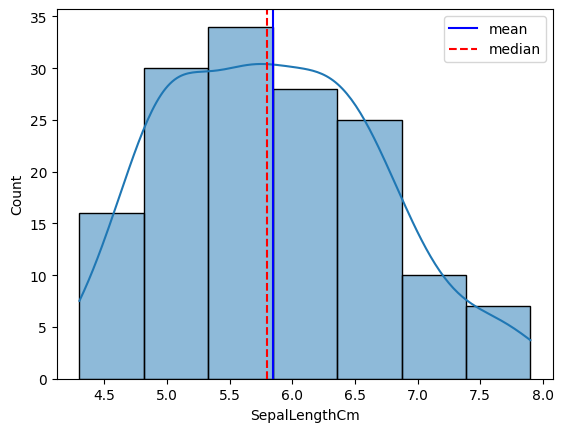

In [15]:
sns.histplot(df['SepalLengthCm'], bins=7, kde=True)
plt.axvline(df['SepalLengthCm'].mean(), color='blue', label='mean')
plt.axvline(df['SepalLengthCm'].median(), color='red', linestyle='--', label='median')
plt.legend()
plt.show()

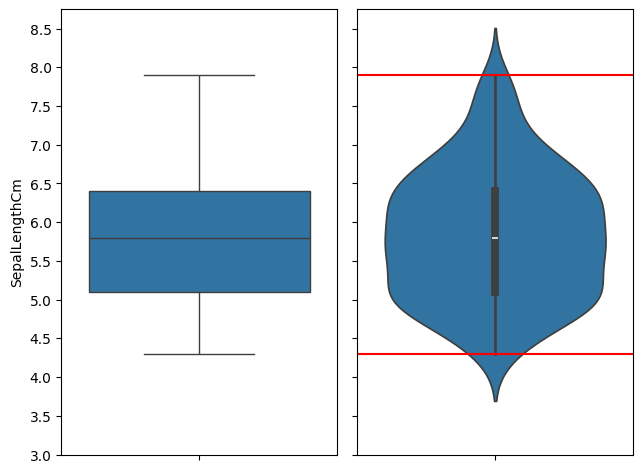

In [16]:
fig, ax = plt.subplots(1, 2, sharey=True)

sns.boxplot(df['SepalLengthCm'], ax=ax[0])
sns.violinplot(df['SepalLengthCm'], ax=ax[1])
ax[1].axhline(y=7.9, color='red')
ax[1].axhline(y=4.3, color='red')
plt.tight_layout()
plt.yticks(np.arange(3, 8.6, 0.5))
plt.show()

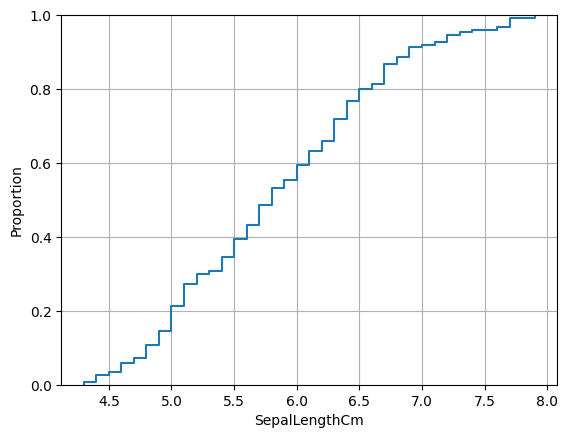

In [17]:
sns.ecdfplot(df['SepalLengthCm'])
plt.grid()
plt.show()

In [18]:
df['SepalLengthCm'].value_counts(bins=5)

(5.74, 6.46]     42
(5.02, 5.74]     41
(4.295, 5.02]    32
(6.46, 7.18]     24
(7.18, 7.9]      11
Name: count, dtype: int64

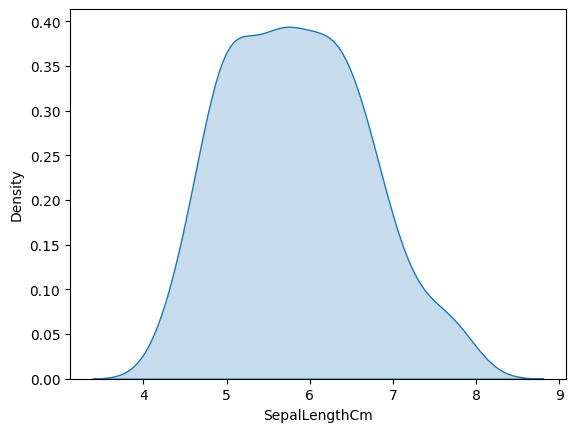

In [19]:
sns.kdeplot(df['SepalLengthCm'], fill=True)
plt.show()

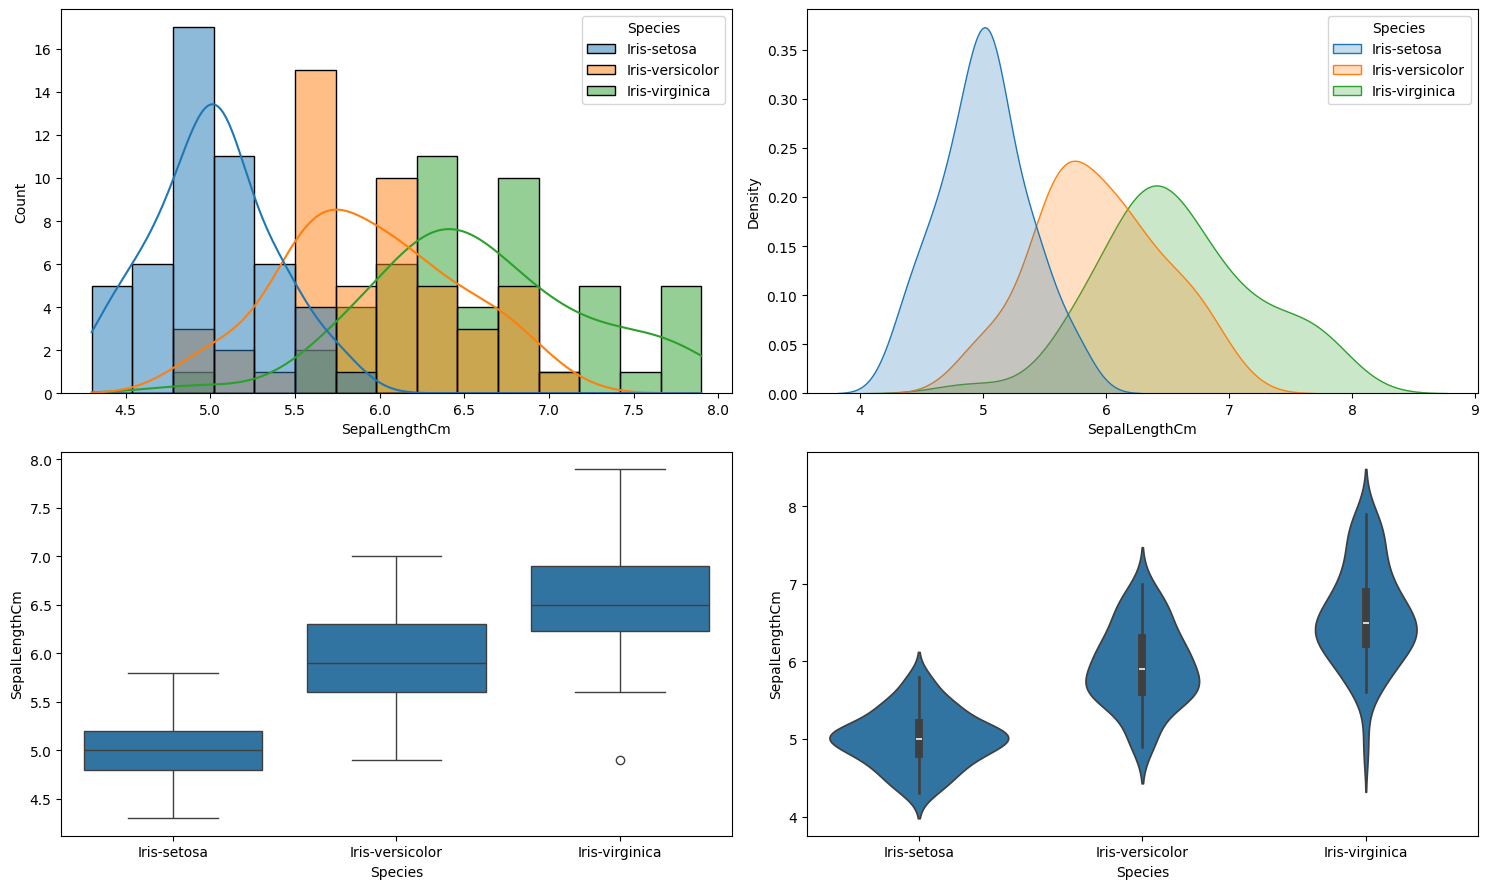

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
sns.histplot(
    data=df,
    x='SepalLengthCm',
    hue='Species',
    kde=True,
    bins=15,
    ax=ax[0, 0]
)
sns.kdeplot(data=df, x='SepalLengthCm', hue='Species', fill=True, ax=ax[0, 1])
sns.boxplot(data=df, x='Species', y='SepalLengthCm', ax=ax[1, 0], )
sns.violinplot(data=df, x='Species', y='SepalLengthCm', ax=ax[1, 1])
plt.tight_layout()
plt.show()

In [21]:
df.groupby('Species')['SepalLengthCm'].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,50.0,5.006,0.352490,4.3,4.800,5.0,5.2,5.8
Iris-versicolor,50.0,5.936,0.516171,4.9,5.600,5.9,6.3,7.0
Iris-virginica,50.0,6.588,0.635880,4.9,6.225,6.5,6.9,7.9


### Выводы по `SepalLengthCm`

- Основная масса наблюдений сосредоточена в центральной части распределения, без выраженного перекоса;
- Среднее значение практически совпадает с медианой, что указывает на отсутствие существенной асимметрии;
- Накопительная функция распределения (ECDF) показывает плавный рост без резких скачков, что свидетельствует о достаточно равномерном распределении значений внутри диапазона;
- Основная часть значений сосредоточена в центральной зоне распределения;
- Явных выбросов не наблюдается;
- Разброс значений можно охарактеризовать как умеренный: значения в основном сосредоточены около среднего без сильного рассеивания по всему диапазону;
- Большинство наблюдений попадает в интервал от 5 до 6.5 см;
- Диапазон значений составляет примерно от 4.3 до 7.9 см;
- Наблюдается частичное разделение данных по классам:

  - каждый вид ириса формирует собственный диапазон значений признака `SepalLengthCm`;
  - это приводит к смещению распределений между классами и формированию нескольких зон концентрации;
  - подтверждается различиями медиан по классам (boxplot);
  - различной формой распределений (violinplot и KDE);
  - наличием нескольких локальных пиков на общем распределении с разбиением по классам (histplot с `hue`).

`SepalWidthCm` - вещественный непрерывный числовой признак

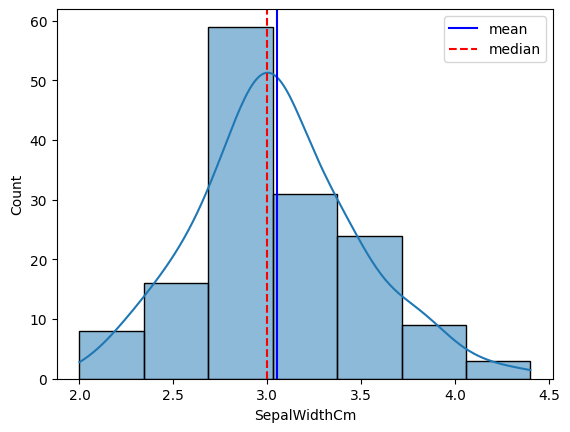

In [22]:
sns.histplot(df['SepalWidthCm'], bins=7, kde=True)
plt.axvline(df['SepalWidthCm'].mean(), color='blue', label='mean')
plt.axvline(df['SepalWidthCm'].median(), color='red', linestyle='--', label='median')
plt.legend()
plt.show()

In [23]:
df['SepalWidthCm'].value_counts(bins=7)

(2.686, 3.029]    59
(3.029, 3.371]    31
(3.371, 3.714]    24
(2.343, 2.686]    16
(3.714, 4.057]     9
(1.997, 2.343]     8
(4.057, 4.4]       3
Name: count, dtype: int64

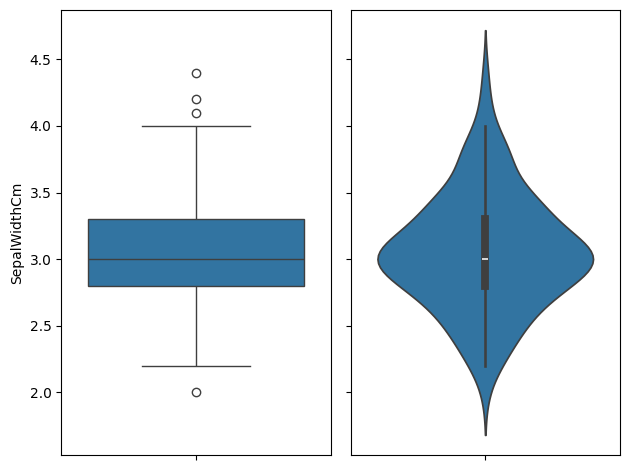

In [24]:
fig, ax = plt.subplots(1, 2, sharey=True)

sns.boxplot(df['SepalWidthCm'], ax=ax[0])
sns.violinplot(df['SepalWidthCm'], ax=ax[1])
plt.tight_layout()
plt.show()

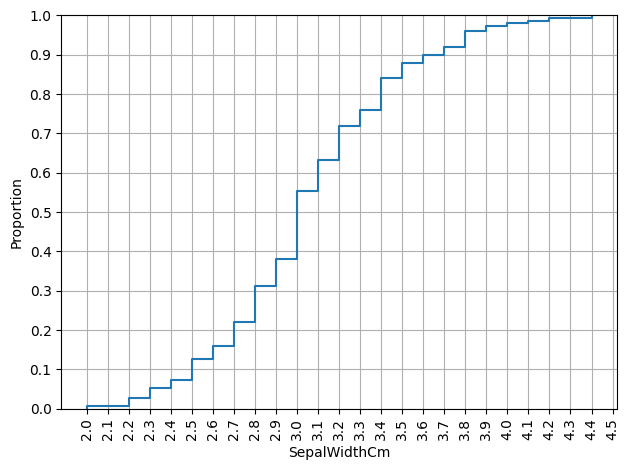

In [25]:
sns.ecdfplot(df['SepalWidthCm'])
plt.grid()
plt.xticks(np.arange(2, 4.6, 0.1), rotation=90)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.tight_layout()
plt.show()

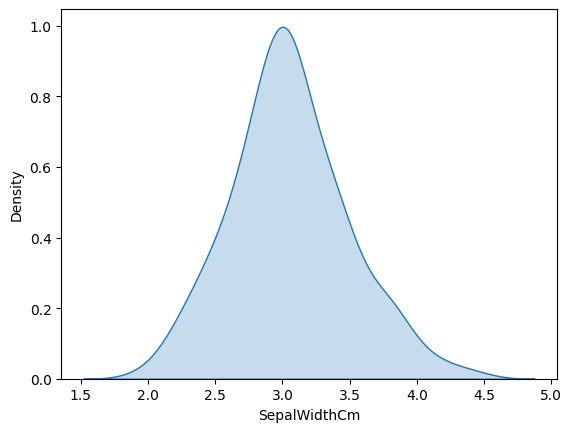

In [26]:
sns.kdeplot(df['SepalWidthCm'], fill=True)
plt.show()

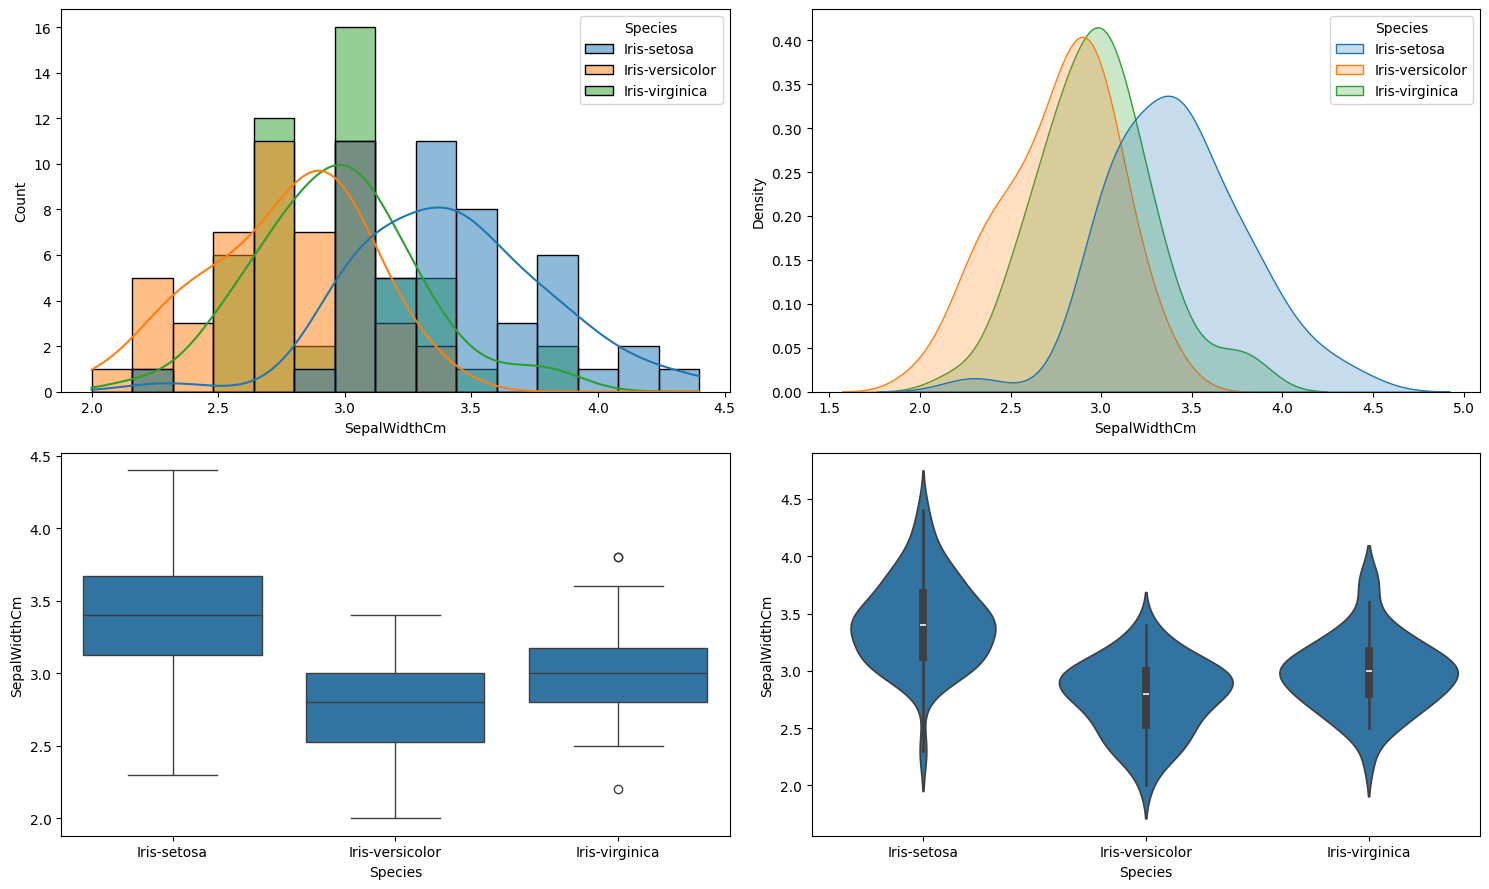

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
sns.histplot(
    data=df,
    x='SepalWidthCm',
    hue='Species',
    kde=True,
    bins=15,
    ax=ax[0, 0]
)
sns.kdeplot(data=df, x='SepalWidthCm', hue='Species', fill=True, ax=ax[0, 1])
sns.boxplot(data=df, x='Species', y='SepalWidthCm', ax=ax[1, 0], )
sns.violinplot(data=df, x='Species', y='SepalWidthCm', ax=ax[1, 1])
plt.tight_layout()
plt.show()

In [28]:
df.groupby('Species')['SepalWidthCm'].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,50.0,3.418,0.381024,2.3,3.125,3.4,3.675,4.4
Iris-versicolor,50.0,2.770,0.313798,2.0,2.525,2.8,3.000,3.4
Iris-virginica,50.0,2.974,0.322497,2.2,2.800,3.0,3.175,3.8


### Выводы по `SepalWidthCm`
- Основная масса наблюдений сосредоточена в центральной части распределения;
- Среднее и медиана почти совпадают, поэтому выраженной асимметрии не наблюдается;
- На ECDF заметен резкий рост в интервале примерно от 2.9 до 3.1, что указывает на высокую концентрацию значений в этой области;
- Распределение нельзя назвать равномерным по всему диапазону, так как в центре наблюдается заметное скопление значений;
- Основная часть значений действительно находится в центральной зоне;
- Boxplot выделяет несколько значений как выбросы по правилу IQR, однако это не обязательно означает ошибку в данных;
- Разброс признака можно охарактеризовать как умеренный: большинство значений сосредоточено около среднего без сильного рассеивания по всему диапазону;
- Минимальное значение составляет 2.0 см, максимальное - 4.4 см;
- По результатам анализа признака `SepalWidthCm` наблюдается слабое частичное разделение классов. Хотя распределения для разных видов ириса имеют различия по средним значениям и форме, они существенно перекрываются между собой.

`PetalLengthCm` - вещественный непрерывный числовой признак

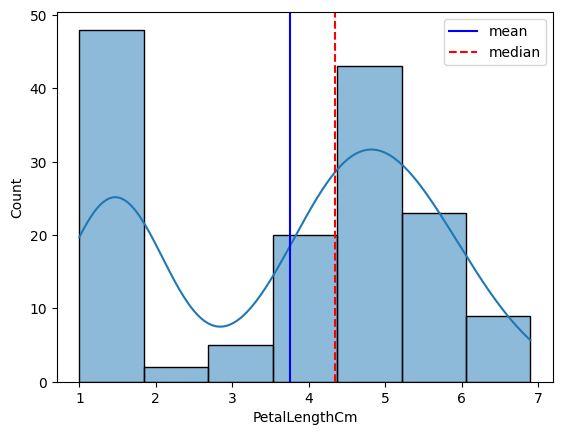

In [29]:
sns.histplot(df['PetalLengthCm'], bins=7, kde=True)
plt.axvline(df['PetalLengthCm'].mean(), color='blue', label='mean')
plt.axvline(df['PetalLengthCm'].median(), color='red', linestyle='--', label='median')
plt.legend()
plt.show()

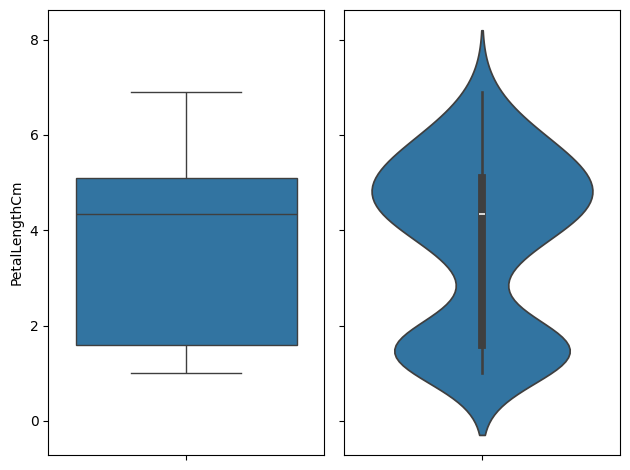

In [30]:
fig, ax = plt.subplots(1, 2, sharey=True)

sns.boxplot(df['PetalLengthCm'], ax=ax[0])
sns.violinplot(df['PetalLengthCm'], ax=ax[1])
plt.tight_layout()
plt.show()

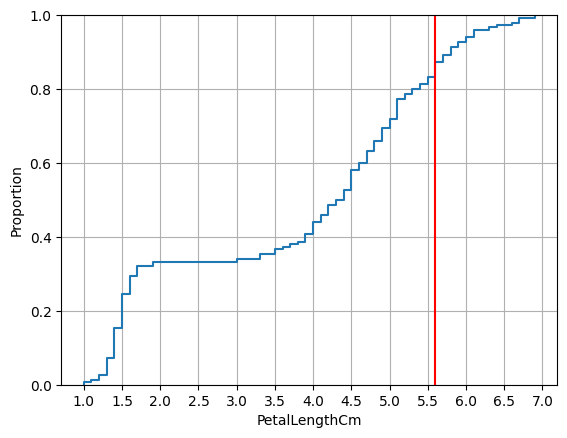

In [31]:
sns.ecdfplot(df['PetalLengthCm'])
plt.grid()
plt.xticks(np.arange(1, 7.1, 0.5))
plt.axvline(x=5.6, color='red')
plt.show()

In [32]:
df['PetalLengthCm'].value_counts(bins=5)

(0.993, 2.18]    50
(4.54, 5.72]     47
(3.36, 4.54]     34
(5.72, 6.9]      16
(2.18, 3.36]      3
Name: count, dtype: int64

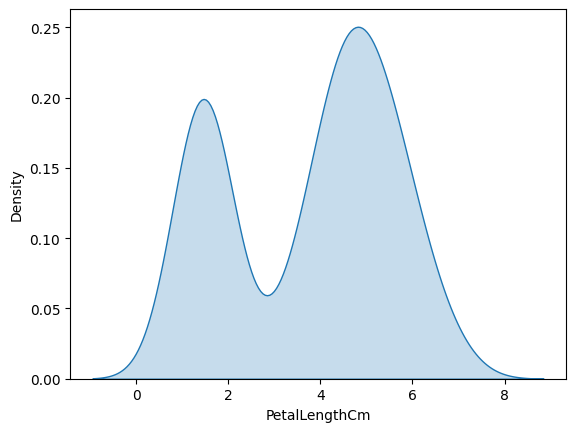

In [33]:
sns.kdeplot(df['PetalLengthCm'], fill=True)
plt.show()

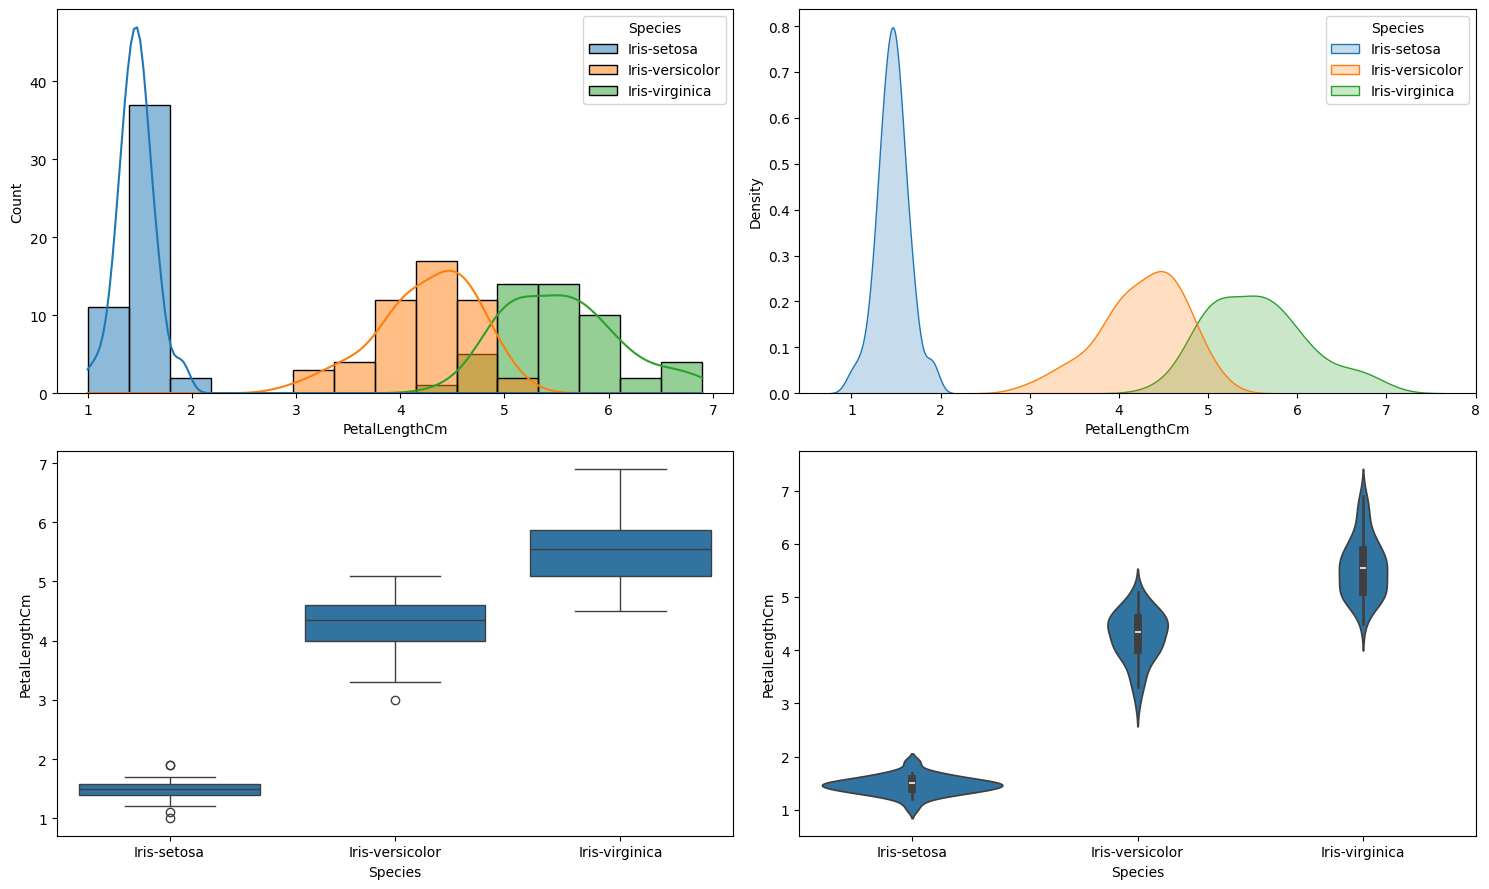

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
sns.histplot(
    data=df,
    x='PetalLengthCm',
    hue='Species',
    kde=True,
    bins=15,
    ax=ax[0, 0]
)
sns.kdeplot(data=df, x='PetalLengthCm', hue='Species', fill=True, ax=ax[0, 1])
sns.boxplot(data=df, x='Species', y='PetalLengthCm', ax=ax[1, 0], )
sns.violinplot(data=df, x='Species', y='PetalLengthCm', ax=ax[1, 1])
plt.tight_layout()
plt.show()

In [35]:
df.groupby('Species')['PetalLengthCm'].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,50.0,1.464,0.173511,1.0,1.4,1.50,1.575,1.9
Iris-versicolor,50.0,4.260,0.469911,3.0,4.0,4.35,4.600,5.1
Iris-virginica,50.0,5.552,0.551895,4.5,5.1,5.55,5.875,6.9


### Выводы по `PetalLengthCm`
- Наблюдаются несколько выраженных групп значений, что указывает на мультимодальное распределение;
- Среднее значение меньше медианы, поэтому присутствует левосторонняя асимметрия, однако основной особенностью признака является не она, а наличие нескольких центров концентрации;
- Накопленная функция растёт неравномерно: в интервале от 2 до 3 см наблюдается разреженность значений, а в диапазонах от 1 до 2 см и от 3.3 до 5.7 см - более высокая концентрация данных;
- Признак не распределён равномерно;
- Основная масса значений сосредоточена в интервалах от 1 до 2 см и от 3.3 до 5.7 см;
- Наибольшая концентрация наблюдается в диапазоне от 1 до 2 см;
- Минимальное значение составляет 1 см, максимальное - 6.9 см.

При разделении по классам распределение признака становится более структурированным и интерпретируемым;
- *Iris-setosa* формирует отдельный компактный диапазон значений (примерно от 1 до 2 см) с высокой концентрацией наблюдений и отсутствием пересечений с другими классами;
- *Iris-versicolor* занимает промежуточный диапазон значений и частично перекрывается с *Iris-virginica*;
- *Iris-virginica* характеризуется наибольшими значениями признака и также частично пересекается с *Iris-versicolor*;
- Таким образом, мультимодальность общего распределения объясняется наложением трёх различных распределений, соответствующих каждому классу.

`PetalWidthCm` - вещественный непрерывный числовой признак

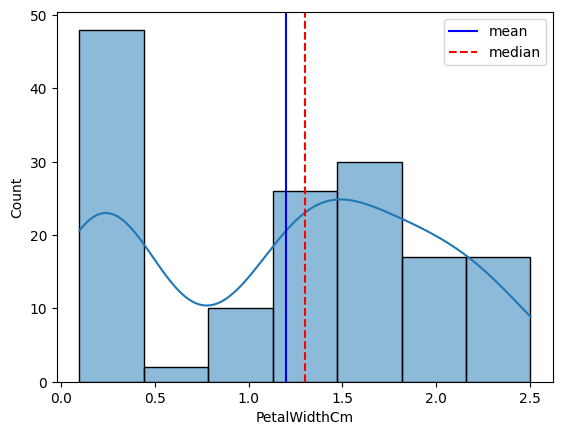

In [36]:
sns.histplot(df['PetalWidthCm'], bins=7, kde=True)
plt.axvline(df['PetalWidthCm'].mean(), color='blue', label='mean')
plt.axvline(df['PetalWidthCm'].median(), color='red', linestyle='--', label='median')
plt.legend()
plt.show()

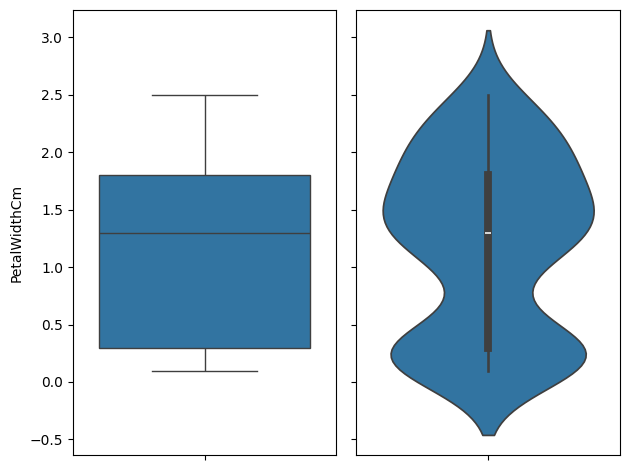

In [37]:
fig, ax = plt.subplots(1, 2, sharey=True)

sns.boxplot(df['PetalWidthCm'], ax=ax[0])
sns.violinplot(df['PetalWidthCm'], ax=ax[1])
plt.tight_layout()
plt.show()

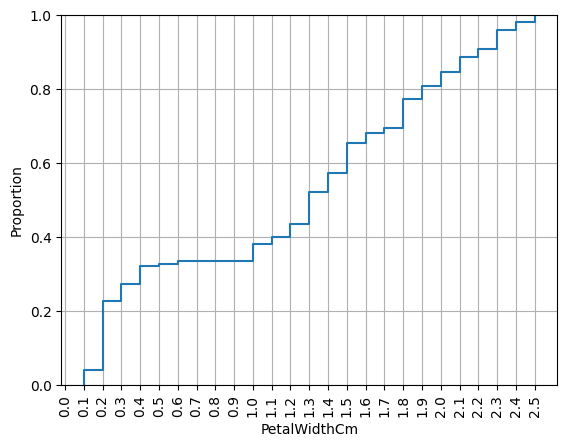

In [38]:
sns.ecdfplot(df['PetalWidthCm'])
plt.grid()
plt.xticks(np.arange(0.0, 2.6, 0.1), rotation=90)
plt.show()

In [39]:
df['PetalWidthCm'].value_counts(bins=5)

(0.0966, 0.58]    49
(1.06, 1.54]      41
(1.54, 2.02]      29
(2.02, 2.5]       23
(0.58, 1.06]       8
Name: count, dtype: int64

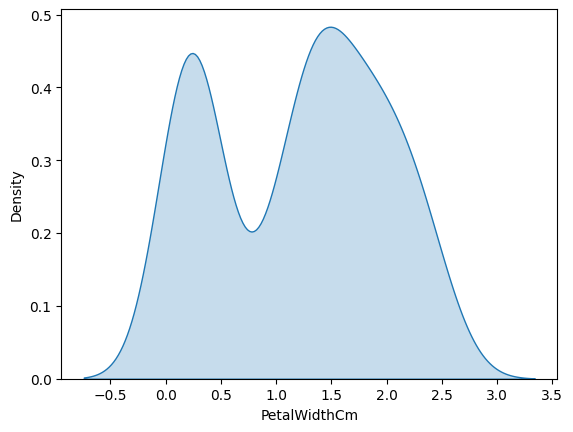

In [40]:
sns.kdeplot(df['PetalWidthCm'], fill=True)
plt.show()

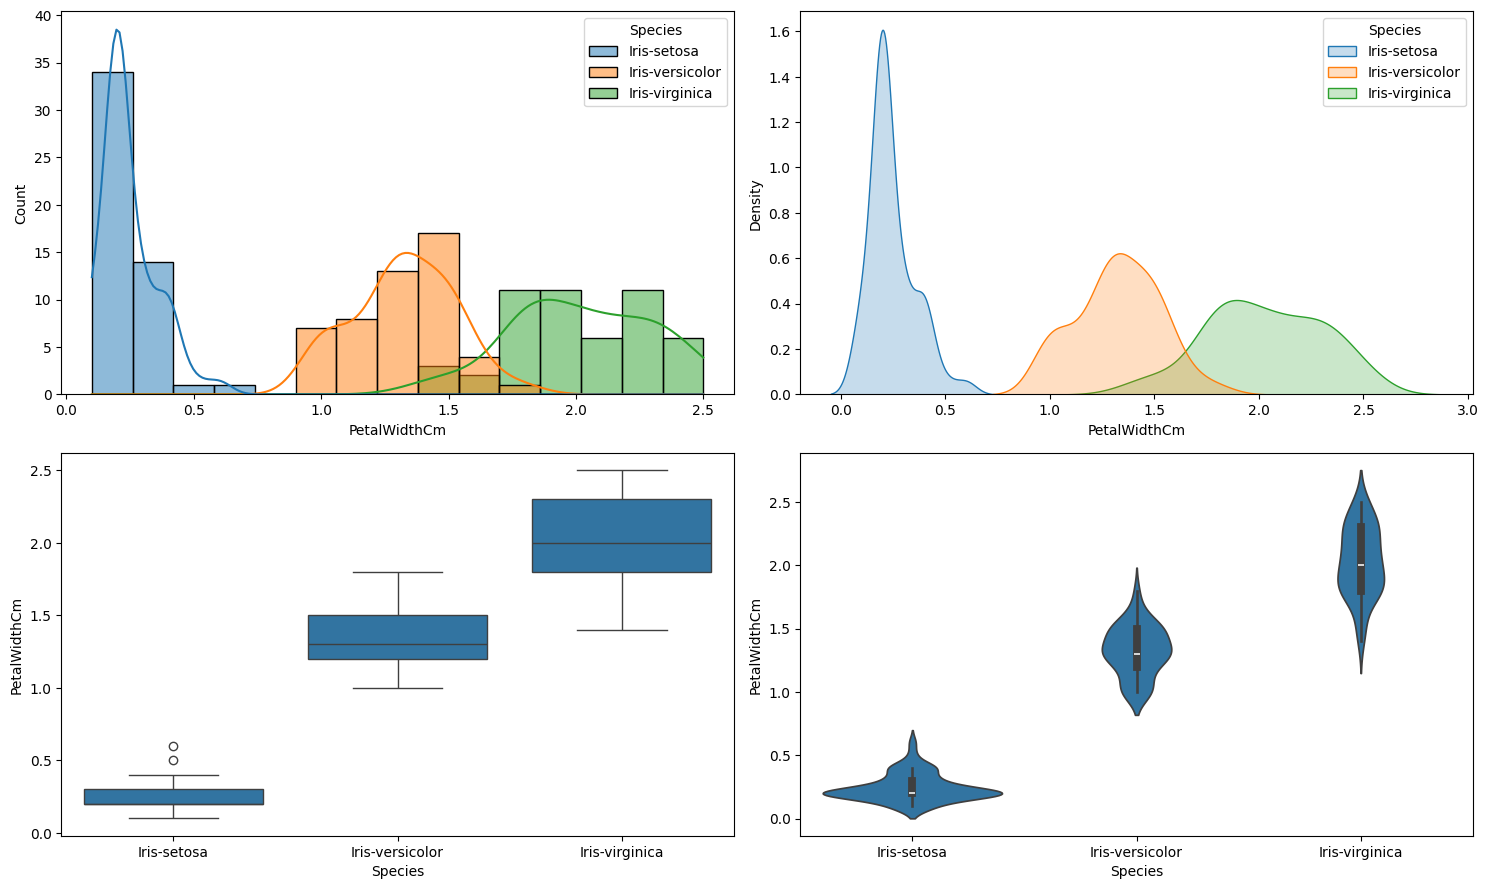

In [41]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
sns.histplot(
    data=df,
    x='PetalWidthCm',
    hue='Species',
    kde=True,
    bins=15,
    ax=ax[0, 0]
)
sns.kdeplot(data=df, x='PetalWidthCm', hue='Species', fill=True, ax=ax[0, 1])
sns.boxplot(data=df, x='Species', y='PetalWidthCm', ax=ax[1, 0], )
sns.violinplot(data=df, x='Species', y='PetalWidthCm', ax=ax[1, 1])
plt.tight_layout()
plt.show()

In [42]:
df.groupby('Species')['PetalWidthCm'].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Iris-setosa,50.0,0.244,0.107210,0.1,0.2,0.2,0.3,0.6
Iris-versicolor,50.0,1.326,0.197753,1.0,1.2,1.3,1.5,1.8
Iris-virginica,50.0,2.026,0.274650,1.4,1.8,2.0,2.3,2.5


### Выводы по `PetalWidthCm`
- Ситуация похожа на ситуацию с `PetalLengthCm`
- Наблюдаются несколько выраженных групп значений, что указывает на мультимодальное распределение;
- Среднее значение меньше медианы, поэтому присутствует левосторонняя асимметрия, однако основной особенностью признака является не она, а наличие нескольких центров концентрации;
- Накопленная функция растёт неравномерно: в интервале от 0.6 до 1.0 см наблюдается разреженность значений, а в окрестности точки 0.2 - более высокая концентрация данных;
- Признак не распределён равномерно;
- Основная масса значений сосредоточена в интервале от 0.1 до 0.58 см и от 1.06 до 1.54 см;
- Наибольшая концентрация наблюдается в диапазоне от 0.1 до 0.58 см
- Минимальное значение составляет 0.1 см, максимальное - 2.5 см.

При разделении по классам распределение признака становится более структурированным и интерпретируемым;
- *Iris-setosa* формирует отдельный компактный диапазон значений (примерно от 0.1 до 0.5 см) с высокой концентрацией наблюдений и отсутствием пересечений с другими классами;
- *Iris-versicolor* занимает промежуточный диапазон значений и частично перекрывается с *Iris-virginica*;
- *Iris-virginica* характеризуется наибольшими значениями признака и также частично пересекается с *Iris-versicolor*;
- Таким образом, мультимодальность общего распределения объясняется наложением трёх различных распределений, соответствующих каждому классу.

## Общий вывод по исследованию всех признаков по одиночке

- `PetalLengthCm` и `PetalWidthCm` лучше всего разделяют классы;
- `SepalLengthCm` разделяет классы частично;
- `SepalWidthCm` разделяет классы слабее остальных, распределения сильно перекрываются;
- `PetalLengthCm` и `PetalWidthCm` выглядят сильно связанными, то есть между ними ожидается сильная положительная корреляция.

## Корреляционный анализ

In [43]:
df_copy = df.copy()
df_copy['Species'] = df_copy['Species'].replace({
    'Iris-setosa': 0,
    'Iris-virginica': 1,
    'Iris-versicolor': 2
})

df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [44]:
corr = df_copy.corr()

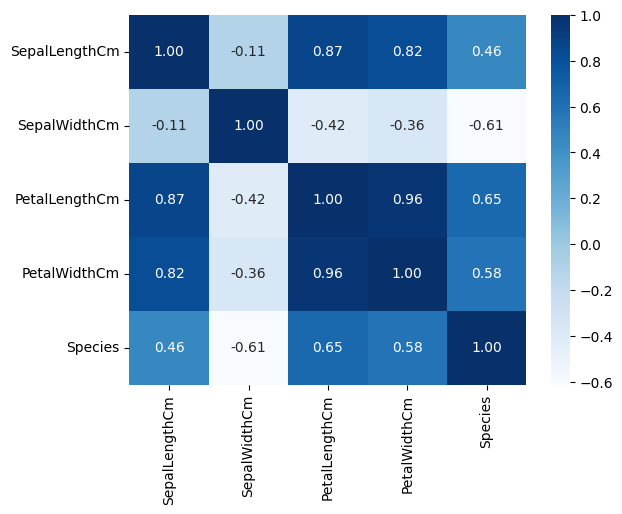

In [45]:
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')
plt.show()

На основании карты корреляции можно сделать вывод:
- `PetalLengthCm` и `PetalWidthCm`, как и ожидалось, обладают очень сильной положительной корреляцией (0.96);
- `SepalLengthCm` также демонстрирует заметную положительную корреляцию с признаками лепестка, что указывает на общую зависимость размеров цветка;
- Между `SepalLengthCm` и `SepalWidthCm` наблюдается слабая отрицательная корреляция, следовательно, явной линейной зависимости между параметрами чашелистика не прослеживается;
- `SepalWidthCm` обладает умеренной связью с признаками лепестка, однако эта зависимость выражена значительно слабее по сравнению с признаками лепестка между собой;
- После кодирования целевой переменной (`Species`) числовыми значениями наблюдается:
  - умеренная корреляция с `SepalLengthCm` и `PetalWidthCm`;
  - более выраженная связь с `PetalLengthCm` и `SepalWidthCm`.

*Корреляция между признаками и целевой переменной `Species` была рассмотрена только в ознакомительных целях, поскольку целевая переменная является категориальной и её числовое кодирование не отражает реальных количественных отношений между классами.

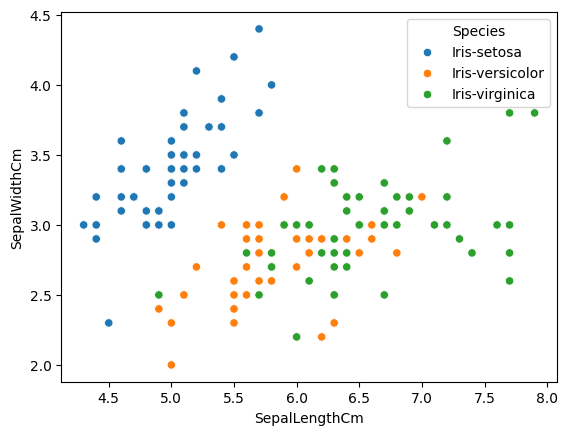

In [46]:
sns.scatterplot(data=df, x='SepalLengthCm', y='SepalWidthCm', hue='Species')
plt.show()

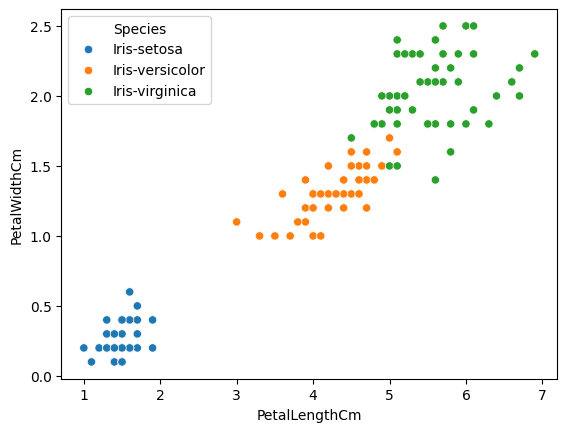

In [47]:
sns.scatterplot(
    data=df,
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species'
)

plt.show()

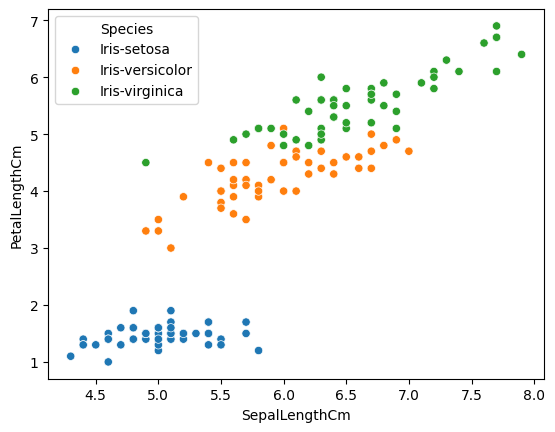

In [48]:
sns.scatterplot(
    data=df,
    x='SepalLengthCm',
    y='PetalLengthCm',
    hue='Species'
)

plt.show()

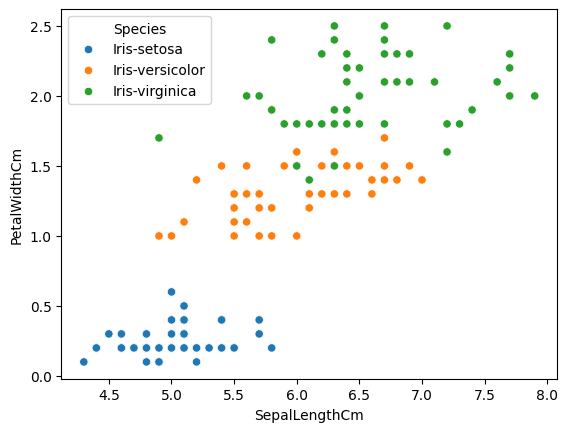

In [49]:
sns.scatterplot(
    data=df,
    x='SepalLengthCm',
    y='PetalWidthCm',
    hue='Species'
)

plt.show()

In [50]:
df_scaled = df.copy()
scaler = StandardScaler()
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
df_scaled[features] = scaler.fit_transform(df[features])
df_scaled

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,-0.900681,1.032057,-1.341272,-1.312977,Iris-setosa
1,-1.143017,-0.124958,-1.341272,-1.312977,Iris-setosa
2,-1.385353,0.337848,-1.398138,-1.312977,Iris-setosa
3,-1.506521,0.106445,-1.284407,-1.312977,Iris-setosa
4,-1.021849,1.263460,-1.341272,-1.312977,Iris-setosa
...,...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956,Iris-virginica
146,0.553333,-1.281972,0.705893,0.922064,Iris-virginica
147,0.795669,-0.124958,0.819624,1.053537,Iris-virginica
148,0.432165,0.800654,0.933356,1.447956,Iris-virginica


In [51]:
pca = PCA(n_components=1)
df_scaled['sepal'] = pca.fit_transform(df_scaled[['SepalLengthCm', 'SepalWidthCm']])
df_scaled['petal'] = pca.fit_transform(df_scaled[['PetalLengthCm', 'PetalWidthCm']])
df_scaled

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,sepal,petal
0,-0.900681,1.032057,-1.341272,-1.312977,Iris-setosa,-1.366652,-1.876838
1,-1.143017,-0.124958,-1.341272,-1.312977,Iris-setosa,-0.719877,-1.876838
2,-1.385353,0.337848,-1.398138,-1.312977,Iris-setosa,-1.218487,-1.917048
3,-1.506521,0.106445,-1.284407,-1.312977,Iris-setosa,-1.140539,-1.836627
4,-1.021849,1.263460,-1.341272,-1.312977,Iris-setosa,-1.615958,-1.876838
...,...,...,...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956,Iris-virginica,0.822339,1.603421
146,0.553333,-1.281972,0.705893,0.922064,Iris-virginica,1.297757,1.151139
147,0.795669,-0.124958,0.819624,1.053537,Iris-virginica,0.650981,1.324525
148,0.432165,0.800654,0.933356,1.447956,Iris-virginica,-0.260561,1.683841


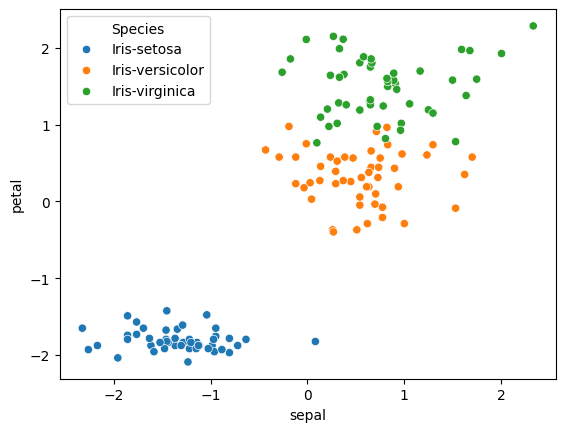

In [52]:
sns.scatterplot(data=df_scaled, x='sepal', y='petal', hue='Species')
plt.show()

In [53]:
df_scaled

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,sepal,petal
0,-0.900681,1.032057,-1.341272,-1.312977,Iris-setosa,-1.366652,-1.876838
1,-1.143017,-0.124958,-1.341272,-1.312977,Iris-setosa,-0.719877,-1.876838
2,-1.385353,0.337848,-1.398138,-1.312977,Iris-setosa,-1.218487,-1.917048
3,-1.506521,0.106445,-1.284407,-1.312977,Iris-setosa,-1.140539,-1.836627
4,-1.021849,1.263460,-1.341272,-1.312977,Iris-setosa,-1.615958,-1.876838
...,...,...,...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956,Iris-virginica,0.822339,1.603421
146,0.553333,-1.281972,0.705893,0.922064,Iris-virginica,1.297757,1.151139
147,0.795669,-0.124958,0.819624,1.053537,Iris-virginica,0.650981,1.324525
148,0.432165,0.800654,0.933356,1.447956,Iris-virginica,-0.260561,1.683841


## Выводы по связи признаков

- Признаки, связанные с лепестками (`PetalLengthCm`, `PetalWidthCm`), демонстрируют наиболее выраженное разделение классов и являются основными информативными признаками датасета;
- Признаки, связанные с чашелистиками (`SepalLengthCm`, `SepalWidthCm`), обладают меньшей разделяющей способностью и характеризуются значительным перекрытием распределений между классами;
- Масштабирование признаков с помощью `StandardScaler` не изменило структуру разделимости классов, так как оно влияет только на масштаб данных, но не на их взаимное расположение;
- Объединение признаков (`Sepal` и `Petal`) в новые составные признаки не привело к улучшению разделимости классов, что указывает на то, что исходное пространство признаков уже достаточно информативно;
- В целом, наилучшую разделяющую способность для задачи классификации обеспечивают признаки лепестков, тогда как признаки чашелистиков играют вспомогательную роль.

## Общий вывод по EDA

- В ходе разведочного анализа датасета Iris было установлено, что набор данных является качественным и хорошо подготовленным для дальнейшего машинного обучения: пропущенные значения отсутствуют, а обнаруженные дубликаты могут объясняться естественным совпадением измерений у разных экземпляров одного вида.

- Анализ отдельных признаков показал, что параметры, связанные с лепестками (`PetalLengthCm`, `PetalWidthCm`), являются наиболее информативными для задачи классификации. Именно по ним наблюдается наиболее выраженное разделение классов: для *Iris-setosa* характерен компактный и хорошо отделённый диапазон значений, тогда как *Iris-versicolor* и *Iris-virginica* частично перекрываются между собой. Признак `SepalLengthCm` обладает средней разделяющей способностью, а `SepalWidthCm` — наименьшей, так как его распределения по классам существенно перекрываются.

- Корреляционный анализ подтвердил сильную взаимосвязь между признаками лепестков, особенно между `PetalLengthCm` и `PetalWidthCm`, что указывает на почти линейную зависимость этих параметров. Признаки чашелистиков связаны между собой значительно слабее, а их связь с классами выражена менее отчётливо.

- Дополнительно было установлено, что масштабирование признаков не меняет структуру разделимости классов, а простое объединение признаков не даёт существенного улучшения. Это означает, что исходное пространство признаков уже содержит достаточно информации для решения задачи, но наибольший вклад в классификацию дают именно признаки лепестков.

- Таким образом, датасет Iris хорошо подходит для обучения и демонстрации методов классификации. Наиболее перспективными признаками для построения модели являются `PetalLengthCm` и `PetalWidthCm`, тогда как `SepalLengthCm` и особенно `SepalWidthCm` играют вспомогательную роль.

## Воспользуемся методом `KNeighborsClassifier` для классификации

In [54]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [55]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

In [58]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thena

In [59]:
pred = model.predict(X_test)

In [60]:
display(accuracy_score(y_test, pred))
display(confusion_matrix(y_test, pred))
display(precision_score(y_test, pred, average='macro'))
display(recall_score(y_test, pred, average='macro'))

1.0

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

1.0

1.0

## Выводы

Модель показала идеальное качество на тестовой выборке, однако для подтверждения устойчивости результата требуется дополнительная проверка с использованием кросс-валидации, так как один разбиенный набор данных не гарантирует стабильность метрик.

Воспользуемся кросс-валидацией

In [61]:
scores = cross_val_score(model, X, y, cv=5)
display(scores)
print("mean:", scores.mean())

array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 1.        ])

mean: 0.96


## Воспользуемся `SVC` и попробуем обучить модель

In [62]:
model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    )
)

In [63]:
scores = cross_val_score(model, X, y, cv=5)
display(scores)
print("mean:", scores.mean())

array([0.96666667, 0.96666667, 0.96666667, 0.93333333, 1.        ])

mean: 0.9666666666666666


## Попробуем использовать `дерево`

In [64]:
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
scores = cross_val_score(model, X, y, cv=5)
display(scores)
print("mean:", scores.mean())

array([0.96666667, 0.96666667, 0.93333333, 1.        , 1.        ])

mean: 0.9733333333333334


## Точность немного повысилась. Попробуем использовать `случайный лес`

In [65]:
rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42
)
scores = cross_val_score(rf, X, y, cv=5)
display(scores)
print("mean:", scores.mean())

array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 1.        ])

mean: 0.96


## Воспользуемся `градиентным бустингом`

In [66]:
model = GradientBoostingClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv)

display(scores)
print("mean:", scores.mean())

array([1.        , 0.96666667, 0.93333333, 0.96666667, 0.9       ])

mean: 0.9533333333333335


In [67]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y_encoded, cv=cv)

print(scores)
print(scores.mean())

[0.96666667 0.96666667 0.9        0.96666667 0.9       ]
0.9400000000000001


## Выводы

Было протестировано несколько моделей классификации:
- `KNeighborsClassifier`;
- `SVC`;
- `DecisionTreeClassifier`;
- `RandomForestClassifier`;
- `GradientBoostingClassifier`;
- `XGBClassifier`.

Все модели показали высокое качество классификации, со средней точностью в диапазоне от ~0.94 до ~0.97 по результатам кросс-валидации.

Наилучший результат продемонстрировал `DecisionTreeClassifier` (~0.97), однако разница между моделями не является значительной, что указывает на относительно простую и хорошо структурированную природу данных.

В целом можно сделать вывод, что:
- датасет является хорошо разделимым в пространстве признаков;
- наиболее информативными являются признаки, связанные с лепестками;
- выбор конкретной модели оказывает меньшее влияние на качество, чем качество самих признаков;
- все рассмотренные модели обеспечивают сопоставимый уровень качества, что подтверждает устойчивость решения задачи классификации.